# Imports:

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.cm as cm
import numpy as np
import torch
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA
from sentence_transformers import SentenceTransformer
from sklearn.preprocessing import StandardScaler

c:\Users\thoma\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Dataset:

For this project we use the Smell Pittsburgh dataset:

In [2]:
df_irregular = pd.read_csv("data/smell.csv")

# Loading external models:

This model is trained on data that includes stopwords and capital letters. So there is minimal extra preprocessing required to make embeddings from the textual data from the dataset.

In [3]:
model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 3773.14it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In order to visualize the data from both the TF-IDF and embeddings, we will use <i>Priciple Component Analasys</i> (PCA) to reduce the dimensions of the textual data.

In [4]:
pca = PCA(n_components=2)

# Text preprocessing

We first try to make an TF-IDF and plot these using PCA.

In [5]:
df_tfidf = df_irregular.copy()

We combine the three different column to create a richer context for better drift detection.

In [6]:
df_tfidf["combined"] = df_tfidf["smell description"].fillna("") + " " + df_tfidf["symptoms"].fillna("") + " " + df_tfidf["additional comments"].fillna("")

In [7]:
tfidf_comments = TfidfVectorizer(stop_words="english", max_features=500)

X_combined= tfidf_comments.fit_transform(df_tfidf["combined"].fillna(""))

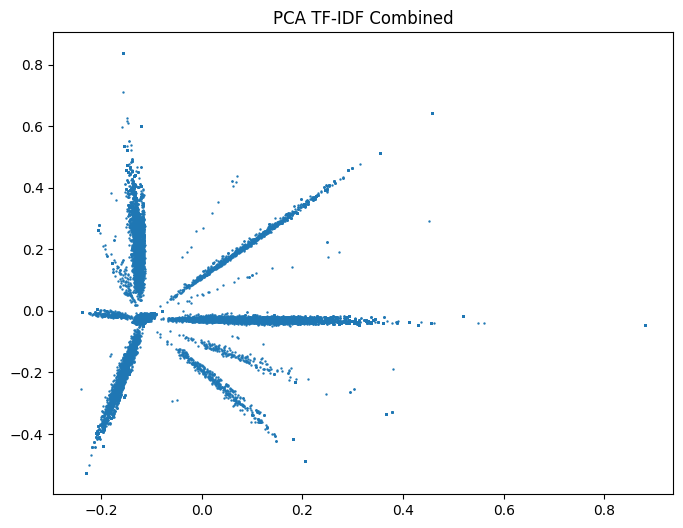

In [8]:
X_pca = PCA(n_components=2).fit_transform(X_combined.toarray())

plt.figure(figsize=(8,6))
plt.title("PCA TF-IDF Combined")
plt.scatter(X_pca[:, 0], X_pca[:, 1], s=0.5)

In the plot above we can see a lot of spikes in the dataset. This is suboptimal for drift detection, since we see very little change in directions. Thus a TF-IDF isn't suited for our problem. A better strategy is to use embeddings.

# Regular Dataset

Creating the regular baseline dataset from the Smell Pittsburgh dataset.

Printing the head of the dataset to compare to the final result.

In [9]:
print(df_irregular.head())

   epoch time                 date & time  smell value  skewed latitude  \
0  1577836610  01/01/2020 00:56:50 +01:00            3        40.557110   
1  1577850486  01/01/2020 04:48:06 +01:00            3        40.423138   
2  1577852394  01/01/2020 05:19:54 +01:00            3        40.381115   
3  1577857682  01/01/2020 06:48:02 +01:00            3        40.307728   
4  1577883411  01/01/2020 13:56:51 +01:00            3        40.307781   

   skewed longitude  zipcode                                smell description  \
0        -80.059578    15237  Sulfur. Hydrogen Sulfide.  Clairton Coke Works.   
1        -79.920387    15217                                       Industrial   
2        -79.860985    15110                                      Industrial    
3        -79.860908    15037                                us steel clairton   
4        -79.860908    15037                               u s steel clairton   

                         symptoms  \
0  Sore throat and lungs.

Initiliaze the regular sampled dataset as a copy of the irregular dataset.

In [10]:
df_regular = df_irregular.copy()

Make the 'date & time' column the index of the new dataset. This is done in order to resample the data in the next step. The column is also made into a <i>datetime</i>, to ensure correct interpertation by pandas.

In [11]:
df_regular["date & time"] = pd.to_datetime(df_regular["date & time"], utc=True)
df_regular = df_regular.set_index("date & time").sort_index()

In [12]:
df_regular = df_regular.resample("1h").agg(count = ("smell value", "size"), mean_smell = ("smell value", "mean"), latitude_mean = ("skewed latitude", "mean"), longitude_mean = ("skewed longitude", "mean"), latitude_std = ("skewed latitude", "std"), longitude_std = ("skewed longitude", "std"))

df_regular["count"] = df_regular["count"].fillna(0)
df_regular["mean_smell"] = df_regular["mean_smell"].fillna(0)
df_regular["latitude_mean"] = df_regular["latitude_mean"].fillna(0)
df_regular["longitude_mean"] = df_regular["longitude_mean"].fillna(0)
df_regular["latitude_std"] = df_regular["latitude_std"].fillna(0)
df_regular["longitude_std"] = df_regular["longitude_std"].fillna(0)


A quick check to see if data is lost after making the data regular.

In [13]:
irregular_count = len(df_irregular)
print("Irregular (raw) number of reports:", irregular_count)

Irregular (raw) number of reports: 75251


In [14]:
count=("smell value", "size")

regular_count = df_regular["count"].sum()
print("Regular (resampled total reports):", regular_count)

Regular (resampled total reports): 75251


In [15]:
df_temp = df_irregular.copy()

## Adding the text data to the regular dataset

We first combine the data together as done with the TF-IDF, afterwards we resample the data to hourly. If there are more reports with text, all the text gets added into one cell.

In [16]:
df_temp["date & time"] = pd.to_datetime(df_temp["date & time"], utc=True)
df_temp = df_temp.set_index("date & time").sort_index()

df_temp["combined"] = (df_temp["smell description"].fillna("") + " " + df_temp["symptoms"].fillna("") + " " + df_temp["additional comments"].fillna(""))

text_hourly = df_temp["combined"].resample("1h").apply(" ".join)

df_regular["combined"] = text_hourly.reindex(df_regular.index, fill_value="")

Now we run the model to create the embeddings of the text.

In [17]:
embeddings = model.encode(df_regular["combined"].tolist())

pca = PCA(n_components=2)
embeddings_2d = pca.fit_transform(embeddings)
 
df_regular["text_emb_1"] = embeddings_2d[:, 0]
df_regular["text_emb_2"] = embeddings_2d[:, 1]

Showing the head of the new dataset to see if the implementation is as expected, which it is.

In [18]:
print(df_regular.head)

<bound method NDFrame.head of                            count  mean_smell  latitude_mean  longitude_mean  \
date & time                                                                   
2019-12-31 23:00:00+00:00      1         3.0      40.557110      -80.059578   
2020-01-01 00:00:00+00:00      0         0.0       0.000000        0.000000   
2020-01-01 01:00:00+00:00      0         0.0       0.000000        0.000000   
2020-01-01 02:00:00+00:00      0         0.0       0.000000        0.000000   
2020-01-01 03:00:00+00:00      1         3.0      40.423138      -79.920387   
...                          ...         ...            ...             ...   
2025-12-31 15:00:00+00:00      0         0.0       0.000000        0.000000   
2025-12-31 16:00:00+00:00      0         0.0       0.000000        0.000000   
2025-12-31 17:00:00+00:00      0         0.0       0.000000        0.000000   
2025-12-31 18:00:00+00:00      0         0.0       0.000000        0.000000   
2025-12-31 19:00:00+00

Saving the dataset as an .csv

In [19]:
df_regular.to_csv("data/smell_regular.csv")

## Visualizing the data

Different plots of the data, based on location and comments a day:

In [20]:
print(df_irregular.columns)

Index(['epoch time', 'date & time', 'smell value', 'skewed latitude',
       'skewed longitude', 'zipcode', 'smell description', 'symptoms',
       'additional comments'],
      dtype='object')


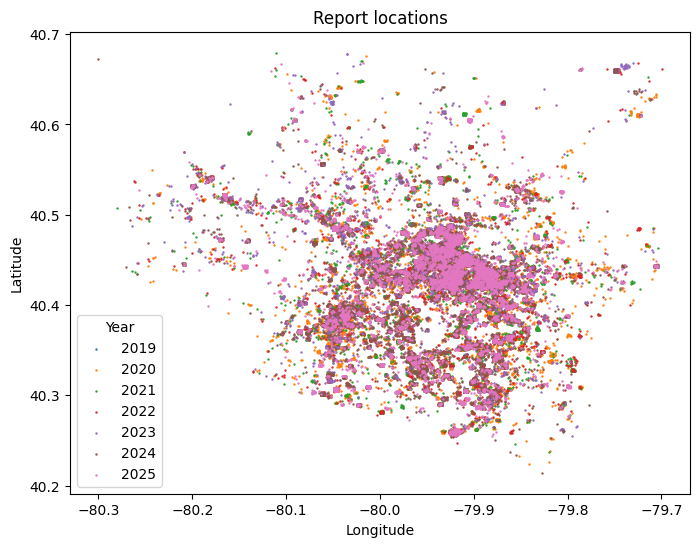

In [21]:
df_irregular["year"] = pd.to_datetime(df_irregular["date & time"], errors="coerce", utc=True)
df_irregular["year"] = df_irregular["year"].dt.year

plt.figure(figsize=(8,6))

for i in df_irregular["year"].dropna().unique():
    subset = df_irregular[df_irregular["year"] == i]
    
    plt.scatter(subset["skewed longitude"], subset["skewed latitude"], label=str(i), s=0.5)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Report locations")
plt.legend(title="Year")

plt.show()

# Implementing the MMD on the regular set

Splitting the features, this way every column is a distinct feature.

In [22]:
features = ["count", "mean_smell", "latitude_mean", "longitude_mean", "latitude_std", "longitude_std", "text_emb_1", "text_emb_2"]

Grouping the features into similar groups. For example latitatude and longitude together, the embeddings together and the smell and count together.

In [23]:
A_idx = [0, 1]
B_idx = [2, 3, 4, 5]
C_idx = [6, 7]

def split_features(X):
    A = X[:, A_idx]
    B = X[:, B_idx]
    C = X[:, C_idx]
    return A, B, C

In [49]:
X = df_regular[features].values.astype(np.float32)

In [50]:
scaler = StandardScaler()
X = scaler.fit_transform(X)

Remove the zero values

In [51]:
mask = df_regular["count"] > 0
X = X[mask.values]

In [52]:
def windows(X, window, step):
    results = []

    for i in range(0, len(X) - window, step):
        results.append(X[i:i + window])
    
    return np.stack(results)

In [53]:
def summarize(windows):
    x = torch.tensor(windows).float()
    
    mean = x.mean(dim=1)
    std = x.std(dim=1)
    trend = x[:, -1] - x[:, 0]
    
    return torch.cat([mean, std, trend], dim=1)

In [54]:
def rbf_kernel(x, y, sigma):
    x2 = (x ** 2).sum(1, keepdim=True)
    y2 = (y ** 2).sum(1, keepdim=True).T

    dist = x2 + y2 - 2 * x @ y.T
    return torch.exp(-dist / (2 * sigma ** 2))

In [55]:
def mmd(x, y, sigma):
    return (rbf_kernel(x, x, sigma).mean() + rbf_kernel(y, y, sigma).mean() - 2 * rbf_kernel(x, y, sigma).mean())

In [56]:
def mmd_multi(X_ref, X_test, window, step, sigma):
    A_ref, B_ref, C_ref = split_features(X_ref)
    A_test, B_test, C_test = split_features(X_test)

    A_ref_w = summarize(windows(A_ref, window, step))
    A_test_w = summarize(windows(A_test, window, step))

    B_ref_w = summarize(windows(B_ref, window, step))
    B_test_w = summarize(windows(B_test, window, step))

    C_ref_w = summarize(windows(C_ref, window, step))
    C_test_w = summarize(windows(C_test, window, step))

    mmd_A = mmd(A_ref_w, A_test_w, sigma)
    mmd_B = mmd(B_ref_w, B_test_w, sigma)
    mmd_C = mmd(C_ref_w, C_test_w, sigma)

    mmd_total = mmd_A + mmd_B + mmd_C

    return mmd_total.item(), mmd_A.item(), mmd_B.item(), mmd_C.item()

In [58]:
def drift_multiview(X, ref_end=200, window=48, step=24, sigma=2.0):

    results = []

    X_ref = X[:ref_end]

    for i in range(ref_end, len(X) - window, step):
        X_test = X[i:i + window * 2]

        total, A, B, C = mmd_multi(X_ref, X_test, window, step, sigma)

        results.append({"total": total, "intensity": A, "spatial": B, "semantic": C})

    return results

In [59]:
def drift(X, ref_end=200, window=48, step=24, sigma=2.0):
    ref = X[:ref_end]
    ref_window = summarize(windows(ref, window, step))

    results = []

    for i in range(ref_end, len(X) - window, step):
        test = X[i:i + window * 2]
        test_window = summarize(windows(test, window, step))

        score = mmd(ref_window, test_window, sigma)

        results.append(score.item())

    return results

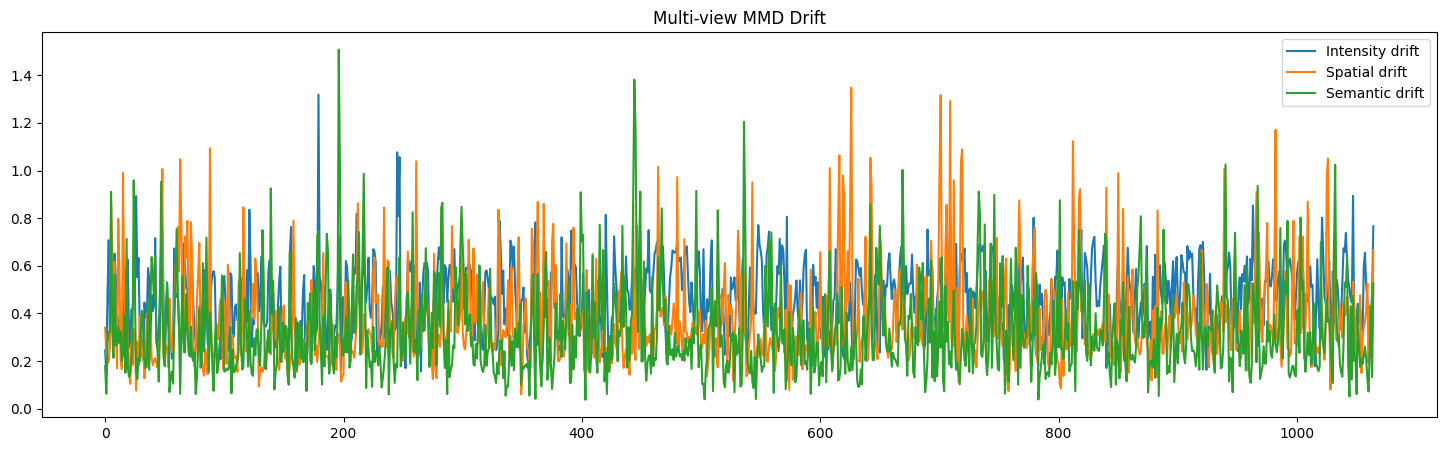

In [65]:
results = drift_multiview(X)

A = [r["intensity"] for r in results]
B = [r["spatial"] for r in results]
C = [r["semantic"] for r in results]

plt.figure(figsize=(18, 5))
plt.plot(A, label="Intensity drift")
plt.plot(B, label="Spatial drift")
plt.plot(C, label="Semantic drift")

plt.legend()
plt.title("Multi-view MMD Drift")
plt.show()

Text(0.5, 1.0, 'MMD Drift Intensity')

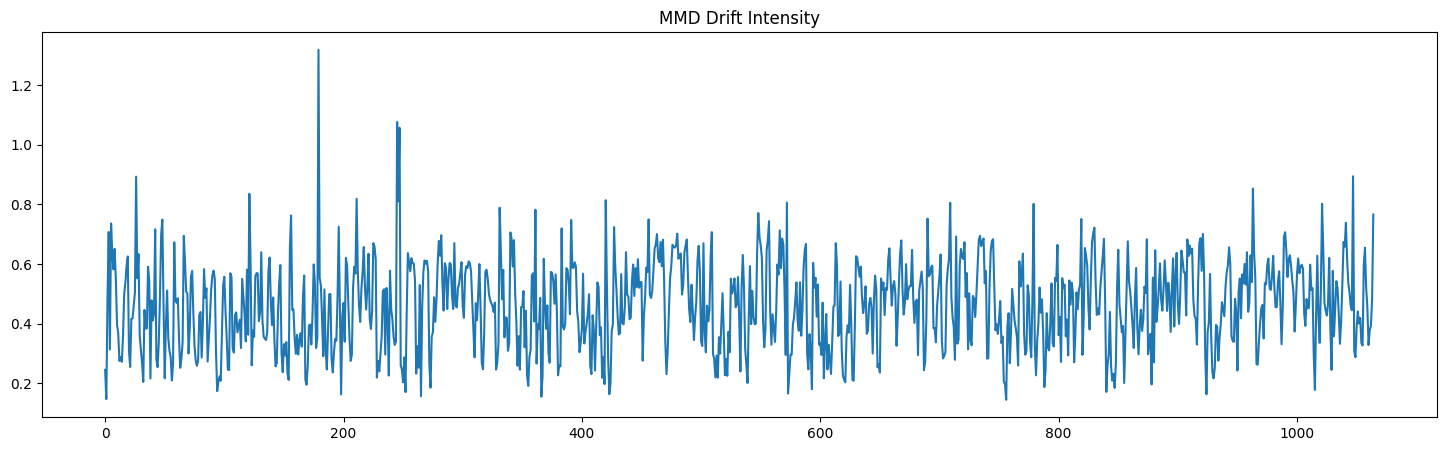

In [61]:
plt.figure(figsize=(18, 5))
plt.plot(A, label="Intensity drift")
plt.title("MMD Drift Intensity")


Text(0.5, 1.0, 'MMD Drift Spatial')

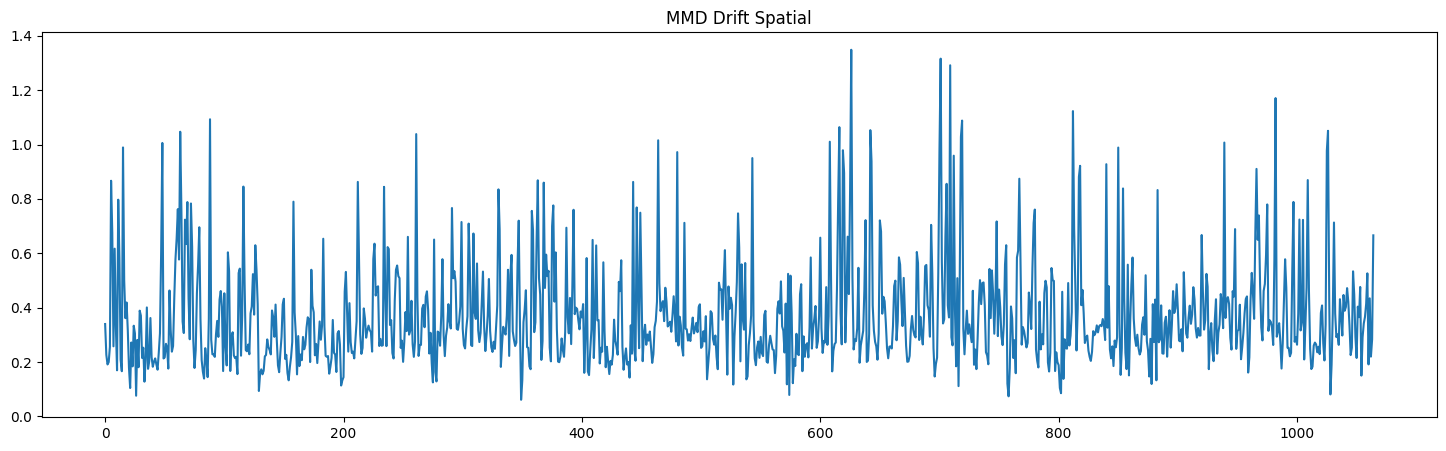

In [62]:
plt.figure(figsize=(18, 5))
plt.plot(B, label="Spatial drift")
plt.title("MMD Drift Spatial")


Text(0.5, 1.0, 'MMD Drift Semantic')

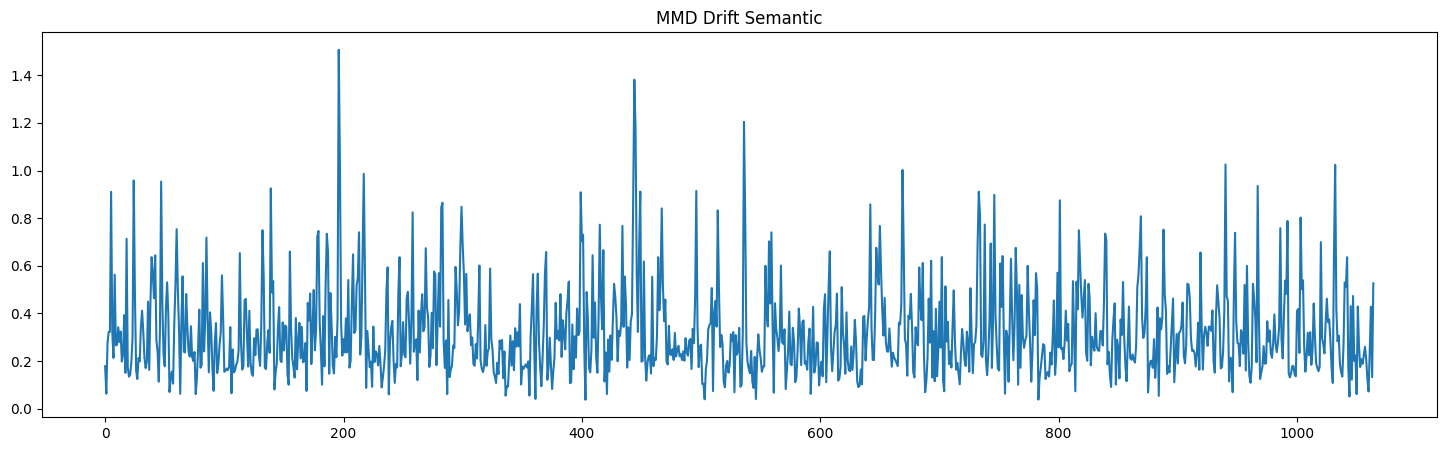

In [63]:
plt.figure(figsize=(18, 5))
plt.plot(C, label="Semantic drift")
plt.title("MMD Drift Semantic")

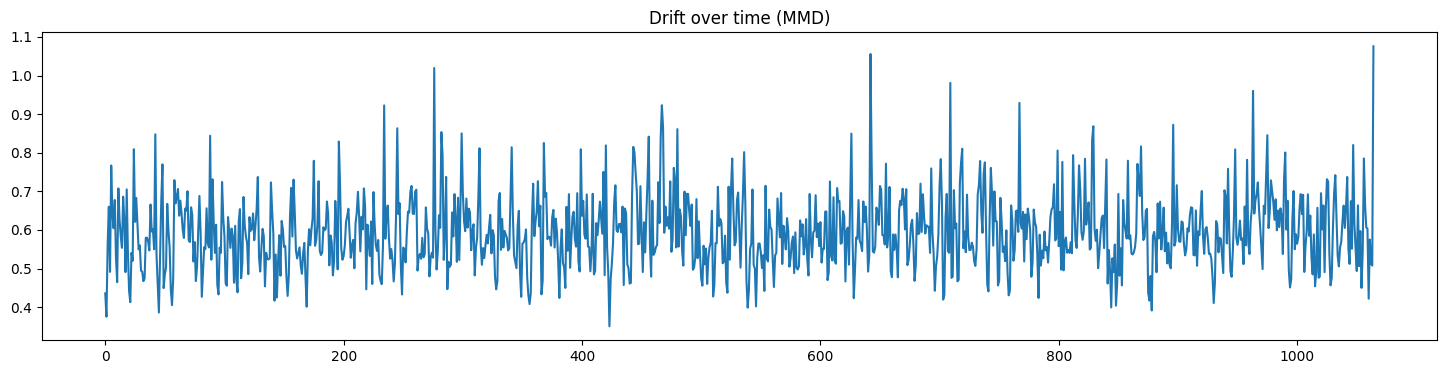

In [64]:
scores = drift(X)

plt.figure(figsize=(18, 4))
plt.plot(scores, label="MMD drift score")
plt.title("Drift over time (MMD)")
plt.show()